<a href="https://colab.research.google.com/github/fecheromero/PNL_tps_Romero_Federico/blob/main/Desafio_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [ ]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from keras.callbacks import EarlyStopping
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout, MultiHeadAttention, Input
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Datos
Utilizaremos como dataset canciones de bandas de habla inglés.

In [ ]:
gdrive_zip_link = "https://drive.google.com/file/d/1_wG7v2ViDE9Ev9ORfufxywamRmrnBBbZ/view?usp=sharing"


In [ ]:
import re

match = re.search(r'id=([a-zA-Z0-9_-]+)', gdrive_zip_link)
if match:
    file_id = match.group(1)
else:
    match = re.search(r'/file/d/([a-zA-Z0-9_-]+)', gdrive_zip_link)
    if match:
        file_id = match.group(1)
    else:
        file_id = None

if file_id:
    print(f'Extracted Google Drive File ID: {file_id}')
else:
    print('Could not extract Google Drive File ID from the provided link.')

Extracted Google Drive File ID: 1_wG7v2ViDE9Ev9ORfufxywamRmrnBBbZ


In [ ]:
try:
    import gdown
except ModuleNotFoundError:
    !pip install gdown
    import gdown

output_path = 'songs_top.zip'
print(f'Attempting to download file with ID: {file_id} to {output_path}')
gdown.download(id=file_id, output=output_path, quiet=False)

Attempting to download file with ID: 1_wG7v2ViDE9Ev9ORfufxywamRmrnBBbZ to songs_top.zip


Downloading...
From: https://drive.google.com/uc?id=1_wG7v2ViDE9Ev9ORfufxywamRmrnBBbZ
To: /content/songs_top.zip
100%|██████████| 105k/105k [00:00<00:00, 3.03MB/s]


'songs_top.zip'

In [ ]:
import os
import zipfile

zip_file_path = 'songs_top.zip'
extract_dir = 'songs_top'

if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f'Successfully extracted {zip_file_path} to {extract_dir}/')
else:
    print(f'Zip file not found at {zip_file_path}')

Successfully extracted songs_top.zip to songs_top/


In [ ]:
import os

# Get a list of all files and directories within the 'songs_dataset' directory
all_files = os.listdir(extract_dir + '/letras top')

# Filter for files that end with '.txt'
lyrics_files = [f for f in all_files if f.endswith('.txt')]

print(f"Found {len(lyrics_files)} .txt files in '{extract_dir}':")
print(lyrics_files[:5]) # Print the first 5 files as an example

Found 101 .txt files in 'songs_top':
['Car_Radio.txt', 'Paladin_Strait.txt', 'The_Craving_Jennas_Version.txt', 'Lovely.txt', 'Ruby.txt']


In [ ]:
all_lyrics = []

for file_name in lyrics_files:
    file_path = os.path.join(extract_dir + "/letras top", file_name)
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                stripped_line = line.strip()
                if stripped_line:
                    all_lyrics.append(stripped_line)
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

print(f"Total {len(all_lyrics)} lyric lines collected from all files.")

Total 4195 lyric lines collected from all files.


In [ ]:
songs_text = " ".join(all_lyrics)
print(songs_text)

Car Radio ========= I ponder of something great My lungs will fill and then deflate They fill with fire, exhale desire I know it's dire my time today I have these thoughts so often I ought To replace that slot with what I once bought 'Cause somebody stole my car radio And now I just sit in silence Sometimes quiet is violent I find it hard to hide it My pride is no longer inside It's on my sleeve, my skin will scream Reminding me of who I killed inside my dream I hate this car that I'm driving There's no hiding for me I'm forced to deal with what I feel There is no distraction to mask what is real I could pull the steering wheel I have these thoughts so often I ought To replace that slot with what I once bought 'Cause somebody stole my car radio And now I just sit in silence I ponder of something terrifying 'Cause this time there's no sound to hide behind I find over the course of our human existence One thing consists of consistence And it's that we're all battling fear Oh, dear, I don

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [ ]:
# seleccionamos el tamaño de contexto
max_context_size = 30

In [ ]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [ ]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(songs_text)

In [ ]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

72

In [ ]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [ ]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in songs_text]

In [ ]:
tokenized_text[:1000]

[29,
 31,
 7,
 40,
 26,
 31,
 64,
 4,
 1,
 40,
 62,
 62,
 62,
 62,
 62,
 62,
 62,
 62,
 62,
 40,
 28,
 40,
 34,
 1,
 42,
 64,
 11,
 7,
 40,
 1,
 51,
 40,
 69,
 1,
 54,
 11,
 38,
 48,
 4,
 42,
 24,
 40,
 24,
 7,
 11,
 31,
 38,
 40,
 63,
 55,
 40,
 19,
 44,
 42,
 24,
 69,
 40,
 56,
 4,
 19,
 19,
 40,
 51,
 4,
 19,
 19,
 40,
 31,
 42,
 64,
 40,
 38,
 48,
 11,
 42,
 40,
 64,
 11,
 51,
 19,
 31,
 38,
 11,
 40,
 9,
 48,
 11,
 55,
 40,
 51,
 4,
 19,
 19,
 40,
 56,
 4,
 38,
 48,
 40,
 51,
 4,
 7,
 11,
 14,
 40,
 11,
 49,
 48,
 31,
 19,
 11,
 40,
 64,
 11,
 69,
 4,
 7,
 11,
 40,
 28,
 40,
 67,
 42,
 1,
 56,
 40,
 4,
 38,
 68,
 69,
 40,
 64,
 4,
 7,
 11,
 40,
 54,
 55,
 40,
 38,
 4,
 54,
 11,
 40,
 38,
 1,
 64,
 31,
 55,
 40,
 28,
 40,
 48,
 31,
 17,
 11,
 40,
 38,
 48,
 11,
 69,
 11,
 40,
 38,
 48,
 1,
 44,
 24,
 48,
 38,
 69,
 40,
 69,
 1,
 40,
 1,
 51,
 38,
 11,
 42,
 40,
 28,
 40,
 1,
 44,
 24,
 48,
 38,
 40,
 9,
 1,
 40,
 7,
 11,
 34,
 19,
 31,
 52,
 11,
 40,
 38,
 48,
 31,
 38,
 40,
 69,
 

### Organizando y estructurando el dataset

In [ ]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [ ]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [ ]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [ ]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [ ]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [ ]:
X.shape

(147736, 30)

In [ ]:
X[0,:10]

array([29, 31,  7, 40, 26, 31, 64,  4,  1, 40])

In [ ]:
y[0,:10]

array([31,  7, 40, 26, 31, 64,  4,  1, 40, 62])

In [ ]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [ ]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, LSTM,  Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [ ]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_8              │ (None, None, 72)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 128)      │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, None, 72)       │         9,288 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,016 (136.78 KB)

 Trainable params: 35,016 (136.78 KB)

 Non-trainable params: 0 (0.00 B)

### modelo extras

In [ ]:
from keras.layers import GRU, Conv1D, Bidirectional

modelGRU1 = Sequential()
modelGRU1.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
modelGRU1.add(GRU(100, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
modelGRU1.add(Dense(vocab_size, activation='softmax'))
modelGRU1.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

modelGRU1.summary()

modelLSTM2 = Sequential()
modelLSTM2.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
modelLSTM2.add(LSTM(90, return_sequences=True, dropout=0.1, recurrent_dropout=0.3 ))
modelLSTM2.add(Dense(vocab_size, activation='softmax'))
modelLSTM2.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

modelLSTM2.summary()





Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_9              │ (None, None, 72)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, None, 100)      │        52,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, None, 72)       │         7,272 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,472 (232.31 KB)

 Trainable params: 59,472 (232.31 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_10             │ (None, None, 72)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, None, 90)       │        58,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, None, 72)       │         6,552 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,232 (254.81 KB)

 Trainable params: 65,232 (254.81 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
modelDobleGRU = Sequential()
modelDobleGRU.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"), input_shape=(None, 1)))
modelDobleGRU.add(GRU(100, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))
modelDobleGRU.add(GRU(100, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))
modelDobleGRU.add(Dense(vocab_size, activation='softmax'))
modelDobleGRU.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

modelDobleGRU.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_11             │ (None, None, 72)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, None, 100)      │        52,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, None, 100)      │        60,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, None, 72)       │         7,272 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,072 (469.03 KB)

 Trainable params: 120,072 (469.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.layers import Input, Embedding, Conv1D, MultiHeadAttention, SpatialDropout1D, LayerNormalization, Dense, Dropout, Add, Bidirectional
from tensorflow.keras.models import Model

modelLstmEmbedding = Sequential()
# Reducimos output_dim para forzar relaciones más densas
modelLstmEmbedding.add(Embedding(input_dim=vocab_size, output_dim=16, input_shape=(None,)))
modelLstmEmbedding.add(Bidirectional(LSTM(90, return_sequences=True))) # Contexto dual
modelLstmEmbedding.add(Dropout(0.2))
modelLstmEmbedding.add(Dense(vocab_size, activation='softmax'))
modelLstmEmbedding.compile(loss='sparse_categorical_crossentropy', optimizer='adam') # Adam suele ser más estable aquí

embed_dim = 16
max_sequence_length = max_context_size # Use max_context_size for positional embedding

# Ejemplo de mejora estructural
inputs = Input(shape=(None,))
x = Embedding(input_dim=vocab_size, output_dim=64)(inputs)

# Opcional: Sumar un vector de posición simple aquí
x = SpatialDropout1D(0.2)(x)

# Convoluciones para patrones locales (bigramas/trigramas)
x = Conv1D(filters=80, kernel_size=5, padding='same', activation='relu')(x)

# Atención con Dropout interno para evitar la memorización
atencion = MultiHeadAttention(num_heads=4, key_dim=16, dropout=0.3)(x, x)
x = LayerNormalization()(x + atencion)

outputs = Dense(vocab_size, activation='softmax')(x)
modelCNNAtencion = Model(inputs=inputs, outputs=outputs)

modelCNNAtencion.compile(loss='sparse_categorical_crossentropy', optimizer='adam')



### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [ ]:
import os

class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl, model_name, save_dir, patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data
      self.history_ppl = history_ppl
      self.model_name = model_name
      self.save_dir = save_dir
      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)

      # Create the save directory if it doesn't exist
      if not os.path.exists(self.save_dir):
          os.makedirs(self.save_dir)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          model_save_path = os.path.join(self.save_dir, f'{self.model_name}.keras')
          self.model.save(model_save_path)
          print(f"Saved new best model to {model_save_path}!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Entrenamiento

In [ ]:
import os
from google.colab import drive

USE_DRIVE = False # Set to True to save models to Google Drive

# Mount Google Drive if USE_DRIVE is True and not already mounted
if USE_DRIVE:
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    drive_save_dir = '/content/drive/MyDrive/saved_models_lyrics_llm'
else:
    drive_save_dir = './saved_models_lyrics_llm'
    if not os.path.exists(drive_save_dir):
        os.makedirs(drive_save_dir) # Create local directory if it doesn't exist

history_ppl = []
early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

model_name_rnn = 'SimpleRNN_model'
model_path_rnn = os.path.join(drive_save_dir, f'{model_name_rnn}.keras')

if os.path.exists(model_path_rnn):
    print(f"Loading existing model: {model_path_rnn}")
    model = keras.models.load_model(model_path_rnn)
else:
    print(f"Training new model: {model_name_rnn}")
    hist = model.fit(X, y, epochs=50, callbacks=[early_stopping, PplCallback(tokenized_sentences_val, history_ppl, model_name_rnn, drive_save_dir)], batch_size=256)


Mounted at /content/drive
Training new model: SimpleRNN_model
Epoch 1/50
577/578 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 2.9621
 mean perplexity: 9.696342308879336 

Saved new best model to /content/drive/MyDrive/saved_models_lyrics_llm/SimpleRNN_model.keras!
578/578 ━━━━━━━━━━━━━━━━━━━━ 90s 150ms/step - loss: 2.6996
Epoch 2/50
577/578 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 2.4390
 mean perplexity: 8.56122937525585 

Saved new best model to /content/drive/MyDrive/saved_models_lyrics_llm/SimpleRNN_model.keras!
578/578 ━━━━━━━━━━━━━━━━━━━━ 90s 156ms/step - loss: 2.4135
Epoch 3/50
577/578 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 2.3515
 mean perplexity: 7.874169157101558 

Saved new best model to /content/drive/MyDrive/saved_models_lyrics_llm/SimpleRNN_model.keras!
578/578 ━━━━━━━━━━━━━━━━━━━━ 81s 140ms/step - loss: 2.3356
Epoch 4/50
577/578 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 2.2956
 mean perplexity: 7.528255222481249 

Saved new best model to /content/drive/MyDrive/saved_mod

In [ ]:
# Train modelGRU1
import os
from google.colab import drive

# Ensure USE_DRIVE and drive_save_dir are defined consistently
try:
    # Check if USE_DRIVE is already defined from a previous cell
    _ = USE_DRIVE
except NameError:
    # If not, define it (e.g., for direct execution of this cell)
    USE_DRIVE = False # Default to False if not set elsewhere

if USE_DRIVE:
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    drive_save_dir = '/content/drive/MyDrive/saved_models_lyrics_llm'
else:
    drive_save_dir = './saved_models_lyrics_llm'
    if not os.path.exists(drive_save_dir):
        os.makedirs(drive_save_dir) # Create local directory if it doesn't exist

model_name_gru = 'GRU_model'
model_path_gru = os.path.join(drive_save_dir, f'{model_name_gru}.keras')
print("\nTraining GRU Model 1:")
history_ppl_gru = []

if os.path.exists(model_path_gru):
    print(f"Loading existing model: {model_path_gru}")
    modelGRU1 = keras.models.load_model(model_path_gru)
else:
    print(f"Training new model: {model_name_gru}")
    hist_gru = modelGRU1.fit(X, y, epochs=50, callbacks=[early_stopping, PplCallback(tokenized_sentences_val, history_ppl_gru, model_name_gru, drive_save_dir)], batch_size=256)

# Train modelLSTM2
model_name_lstm = 'LSTM_model'
model_path_lstm = os.path.join(drive_save_dir, f'{model_name_lstm}.keras')
print("\nTraining LSTM Model 2:")
history_ppl_lstm = []

if os.path.exists(model_path_lstm):
    print(f"Loading existing model: {model_path_lstm}")
    modelLSTM2 = keras.models.load_model(model_path_lstm)
else:
    print(f"Training new model: {model_name_lstm}")
    hist_lstm = modelLSTM2.fit(X, y, epochs=50, callbacks=[early_stopping, PplCallback(tokenized_sentences_val, history_ppl_lstm, model_name_lstm, drive_save_dir)], batch_size=256)

# Train modelDobleGRU
model_name_doblegru = 'DobleGRU_model'
model_path_doblegru = os.path.join(drive_save_dir, f'{model_name_doblegru}.keras')
print("\nTraining Doble GRU Model:")
history_ppl_doble_gru = []

if os.path.exists(model_path_doblegru):
    print(f"Loading existing model: {model_path_doblegru}")
    modelDobleGRU = keras.models.load_model(model_path_doblegru)
else:
    print(f"Training new model: {model_name_doblegru}")
    hist_doble_gru = modelDobleGRU.fit(X, y, epochs=50, callbacks=[early_stopping, PplCallback(tokenized_sentences_val, history_ppl_doble_gru, model_name_doblegru, drive_save_dir)], batch_size=256)

# Train modelLstmEmbedding
model_name_lstm_embedding = 'LstmEmbedding_model'
model_path_lstm_embedding = os.path.join(drive_save_dir, f'{model_name_lstm_embedding}.keras')
print("\nTraining LSTM with Embedding Model:")
history_ppl_lstm_embedding = []

if os.path.exists(model_path_lstm_embedding):
    print(f"Loading existing model: {model_path_lstm_embedding}")
    modelLstmEmbedding = keras.models.load_model(model_path_lstm_embedding)
else:
    print(f"Training new model: {model_name_lstm_embedding}")
    hist_lstm_embedding = modelLstmEmbedding.fit(X, y, epochs=50, callbacks=[early_stopping, PplCallback(tokenized_sentences_val, history_ppl_lstm_embedding, model_name_lstm_embedding, drive_save_dir)], batch_size=256)

# Train modelConvAttention
model_name_attention = 'Conv_Attention_model'
model_path_attention = os.path.join(drive_save_dir, f'{model_name_attention}.keras')
print("\nTraining conv Attention Model:")
history_ppl_attention = []

if os.path.exists(model_path_attention):
    print(f"Loading existing model: {model_path_attention}")
    modelCNNAtencion = keras.models.load_model(model_path_attention)
else:
    print(f"Training new model: {model_name_attention}")
    hist_attention = modelCNNAtencion.fit(X, y, epochs=50, callbacks=[early_stopping, PplCallback(tokenized_sentences_val, history_ppl_attention, model_name_attention, drive_save_dir)], batch_size=256)



Training GRU Model 1:
Training new model: GRU_model
Epoch 1/50
577/578 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - loss: 2.9688
 mean perplexity: 9.083466148638463 

Saved new best model to /content/drive/MyDrive/saved_models_lyrics_llm/GRU_model.keras!
578/578 ━━━━━━━━━━━━━━━━━━━━ 197s 333ms/step - loss: 2.6119
Epoch 2/50
577/578 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 2.2026
 mean perplexity: 7.597719374593797 

Saved new best model to /content/drive/MyDrive/saved_models_lyrics_llm/GRU_model.keras!
578/578 ━━━━━━━━━━━━━━━━━━━━ 159s 275ms/step - loss: 2.1457
Epoch 3/50
577/578 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 2.0089
 mean perplexity: 6.919260949878902 

Saved new best model to /content/drive/MyDrive/saved_models_lyrics_llm/GRU_model.keras!
578/578 ━━━━━━━━━━━━━━━━━━━━ 158s 273ms/step - loss: 1.9766
Epoch 4/50
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 1.8947
 mean perplexity: 6.603589511179662 

Saved new best model to /content/drive/MyDrive/saved_models_lyrics_llm/GRU_

In [ ]:
# Prepare data for comparison
model_names = ['SimpleRNN', 'GRU', 'LSTM', 'DobleGRU', 'LstmEmbedding', 'Attention']

# Ensure history_ppl, history_ppl_gru, history_ppl_lstm are not empty before accessing elements
perplexities_epoch_1 = []
perplexities_final_epoch = []

# SimpleRNN
if history_ppl:
    perplexities_epoch_1.append(history_ppl[0])
    perplexities_final_epoch.append(history_ppl[-1])
else:
    perplexities_epoch_1.append(np.nan)
    perplexities_final_epoch.append(np.nan)

# GRU
if history_ppl_gru:
    perplexities_epoch_1.append(history_ppl_gru[0])
    perplexities_final_epoch.append(history_ppl_gru[-1])
else:
    perplexities_epoch_1.append(np.nan)
    perplexities_final_epoch.append(np.nan)

# LSTM
if history_ppl_lstm:
    perplexities_epoch_1.append(history_ppl_lstm[0])
    perplexities_final_epoch.append(history_ppl_lstm[-1])
else:
    perplexities_epoch_1.append(np.nan)
    perplexities_final_epoch.append(np.nan)

# DobleGRU
if history_ppl_doble_gru:
    perplexities_epoch_1.append(history_ppl_doble_gru[0])
    perplexities_final_epoch.append(history_ppl_doble_gru[-1])
else:
    perplexities_epoch_1.append(np.nan)
    perplexities_final_epoch.append(np.nan)

# LstmEmbedding
if history_ppl_lstm_embedding:
    perplexities_epoch_1.append(history_ppl_lstm_embedding[0])
    perplexities_final_epoch.append(history_ppl_lstm_embedding[-1])
else:
    perplexities_epoch_1.append(np.nan)
    perplexities_final_epoch.append(np.nan)

# Attention
if history_ppl_attention:
    perplexities_epoch_1.append(history_ppl_attention[0])
    perplexities_final_epoch.append(history_ppl_attention[-1])
else:
    perplexities_epoch_1.append(np.nan)
    perplexities_final_epoch.append(np.nan)

# Create pandas DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Perplexity_Epoch_1': perplexities_epoch_1,
    'Perplexity_Final_Epoch': perplexities_final_epoch
})

print("\nModel Perplexity Comparison:")
print(comparison_df.to_string())


Model Perplexity Comparison:
           Model  Perplexity_Epoch_1  Perplexity_Final_Epoch
0      SimpleRNN            9.696342                6.696904
1            GRU            9.083466                7.167223
2           LSTM           12.400061                8.505507
3       DobleGRU            9.301360                6.496775
4  LstmEmbedding           11.848031                6.845045
5      Attention            9.484849                7.820744


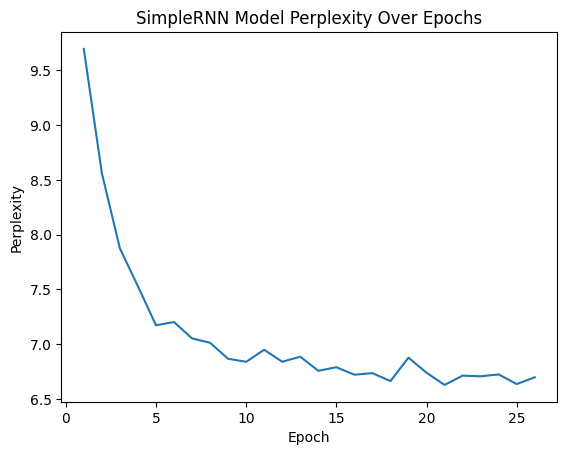

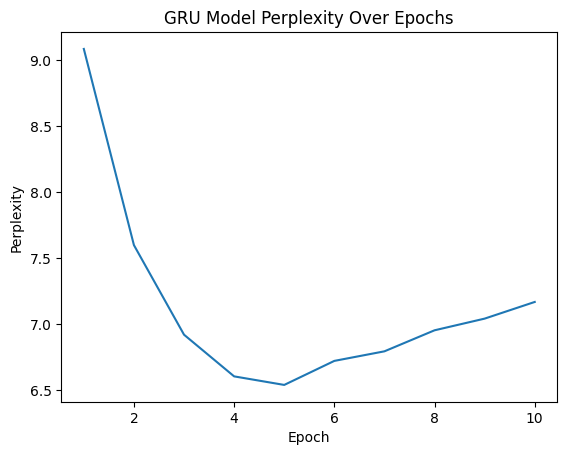

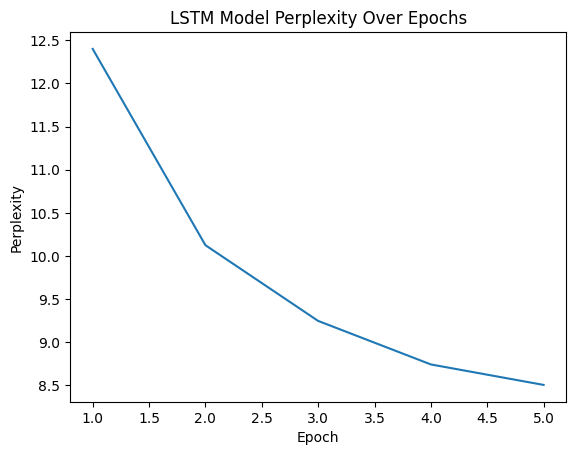

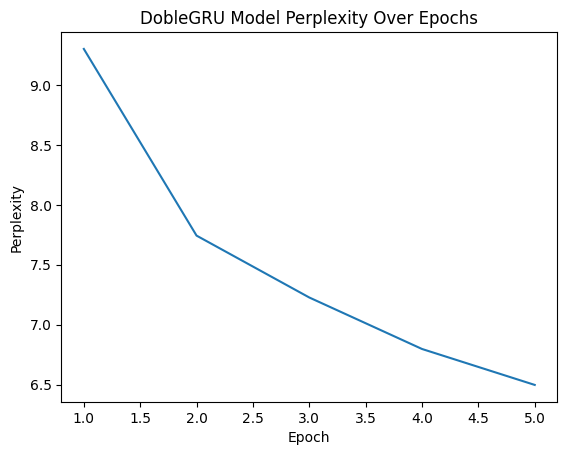

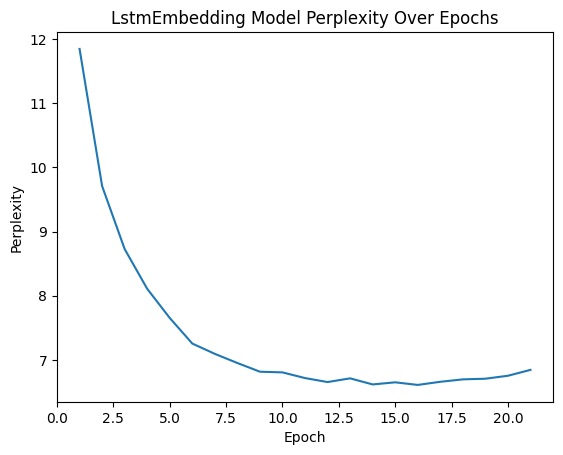

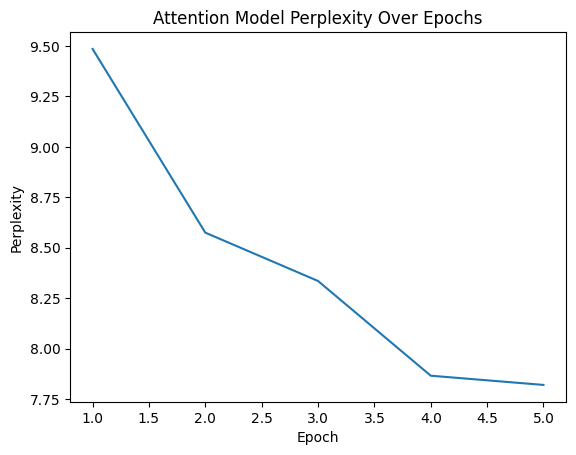

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for SimpleRNN (original model)
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count, y=history_ppl)
plt.title('SimpleRNN Model Perplexity Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.show()

# Plot for GRU Model
if history_ppl_gru:
    epoch_count_gru = range(1, len(history_ppl_gru) + 1)
    sns.lineplot(x=epoch_count_gru, y=history_ppl_gru)
    plt.title('GRU Model Perplexity Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.show()
else:
    print("GRU model history_ppl_gru is empty, cannot plot.")

# Plot for LSTM Model
if history_ppl_lstm:
    epoch_count_lstm = range(1, len(history_ppl_lstm) + 1)
    sns.lineplot(x=epoch_count_lstm, y=history_ppl_lstm)
    plt.title('LSTM Model Perplexity Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.show()
else:
    print("LSTM model history_ppl_lstm is empty, cannot plot.")

# Plot for DobleGRU Model
if history_ppl_doble_gru:
    epoch_count_doble_gru = range(1, len(history_ppl_doble_gru) + 1)
    sns.lineplot(x=epoch_count_doble_gru, y=history_ppl_doble_gru)
    plt.title('DobleGRU Model Perplexity Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.show()
else:
    print("DobleGRU model history_ppl_doble_gru is empty, cannot plot.")

# Plot for LstmEmbedding Model
if history_ppl_lstm_embedding:
    epoch_count_lstm_embedding = range(1, len(history_ppl_lstm_embedding) + 1)
    sns.lineplot(x=epoch_count_lstm_embedding, y=history_ppl_lstm_embedding)
    plt.title('LstmEmbedding Model Perplexity Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.show()
else:
    print("LstmEmbedding model history_ppl_lstm_embedding is empty, cannot plot.")

# Plot for Attention Model
if history_ppl_attention:
    epoch_count_attention = range(1, len(history_ppl_attention) + 1)
    sns.lineplot(x=epoch_count_attention, y=history_ppl_attention)
    plt.title('Attention Model Perplexity Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.show()
else:
    print("Attention model history_ppl_attention is empty, cannot plot.")

### Generación de secuencias

###  Beam search y muestreo aleatorio

In [ ]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [ ]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from scipy.special import softmax
import tensorflow as tf # Import tensorflow

# Helper functions for encoding based on model input type
def encode_for_timedistributed(text_seq, max_length):
    # text_seq can be a string or a list/numpy array of token IDs
    if isinstance(text_seq, str):
        encoded = [char2idx[ch] for ch in text_seq]
    else: # assume it's already token IDs
        encoded = text_seq
    padded = pad_sequences([encoded], maxlen=max_length, padding='pre')
    return np.expand_dims(padded, axis=-1).astype(np.int32) # Shape (1, max_length, 1)

def encode_for_embedding(text_seq, max_length):
    # text_seq can be a string or a list/numpy array of token IDs
    if isinstance(text_seq, str):
        encoded = [char2idx[ch] for ch in text_seq]
    else: # assume it's already token IDs
        encoded = text_seq
    padded = pad_sequences([encoded], maxlen=max_length, padding='pre')
    return padded.astype(np.int32) # Shape (1, max_length)

# Updated generate_seq function
def generate_seq(model, seed_text, max_length_context, n_words, is_timedistributed_input=True):
    output_text = seed_text
    for _ in range(n_words):
        # Use only the tail of the current output_text if it exceeds max_length_context
        current_input_text = output_text[-max_length_context:] if len(output_text) > max_length_context else output_text

        if is_timedistributed_input:
            encoded_input = encode_for_timedistributed(current_input_text.lower(), max_length_context)
        else:
            encoded_input = encode_for_embedding(current_input_text.lower(), max_length_context)

        # Explicitly convert to tf.Tensor before prediction
        y_hat = np.argmax(model.predict(tf.convert_to_tensor(encoded_input), verbose=0)[0, -1, :])
        out_word = idx2char[y_hat]
        output_text += out_word
    return output_text

# The `select_candidates` function remains as defined in cell I_lZiQwkW1Hl
# (Copied here for self-containment if this cell is run independently)
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):
  pred_large = []
  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])
  pred_large = np.array(pred_large)

  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams]
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)

# Updated beam_search function with batch prediction
def beam_search(model, num_beams, num_words, input_text_seed, max_length_context, temp=1, mode='det', is_timedistributed_input=True):

    # Get the initial encoded input in the correct shape (batch, seq_len, features) or (batch, seq_len)
    if is_timedistributed_input:
        initial_encoded_for_predict = encode_for_timedistributed(input_text_seed, max_length_context)
    else:
        initial_encoded_for_predict = encode_for_embedding(input_text_seed, max_length_context)

    # Explicitly convert to tf.Tensor before first prediction
    y_hat = model.predict(tf.convert_to_tensor(initial_encoded_for_predict), verbose=0)[0, -1, :]
    vocab_size = y_hat.shape[0]

    history_probs = [0.0] * num_beams

    # For select_candidates, we need a list of 1D token sequences.
    # So, flatten the initial_encoded_for_predict[0] (which is the single sequence without batch dim)
    if is_timedistributed_input:
        initial_tokens_1d = initial_encoded_for_predict[0].flatten() # (max_length,)
    else:
        initial_tokens_1d = initial_encoded_for_predict[0] # (max_length,)

    history_tokens_for_select = [list(initial_tokens_1d)] * num_beams

    history_probs, history_tokens_np = select_candidates(
        [y_hat], num_beams, vocab_size, history_probs, history_tokens_for_select, temp, mode
    )
    history_tokens = [list(seq) for seq in history_tokens_np] # These are lists of 1D token IDs

    for _ in range(num_words - 1):
        batch_inputs_for_prediction = []
        for hist_seq in history_tokens: # hist_seq is a 1D list of token IDs
            # Re-encode the current sequence (hist_seq) to feed into the model, maintaining max_length_context and shape
            if is_timedistributed_input:
                input_for_prediction = encode_for_timedistributed(hist_seq, max_length_context)
            else:
                input_for_prediction = encode_for_embedding(hist_seq, max_length_context)
            batch_inputs_for_prediction.append(input_for_prediction)

        # Stack all inputs into a single batch for prediction
        batched_input = np.vstack(batch_inputs_for_prediction)

        # Perform a single batch prediction
        batched_predictions = model.predict(tf.convert_to_tensor(batched_input), verbose=0)

        preds = []
        # Extract the relevant predictions (last token's prediction) for each beam
        for i in range(num_beams):
            preds.append(batched_predictions[i, -1, :])

        history_probs, history_tokens_np = select_candidates(
            preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode
        )
        history_tokens = [list(seq) for seq in history_tokens_np]

    return history_tokens[0]


# Define models and their input types
model_dict_with_flags = {
    "SimpleRNN": {"model": model, "is_timedistributed": True},
    "GRU": {"model": modelGRU1, "is_timedistributed": True},
    "LSTM": {"model": modelLSTM2, "is_timedistributed": True},
    "DobleGRU": {"model": modelDobleGRU, "is_timedistributed": True},
    "LstmEmbedding": {"model": modelLstmEmbedding, "is_timedistributed": False},
    "AttentionCNN": {"model": modelCNNAtencion, "is_timedistributed": False}
}

input_text = 'can you save'
num_beams = 10
num_words_beam = 20 # for beam_search
n_words_greedy = 30 # for generate_seq

all_generated_results = {}

tf.config.run_functions_eagerly(True)

for model_name, model_info in model_dict_with_flags.items():
    current_model = model_info["model"]
    is_timedistributed_input = model_info["is_timedistributed"]
    print(f"\n--- Generating sequences for {model_name} ---")
    model_results = {}

    # Greedy search
    greedy_output = generate_seq(current_model, input_text, max_context_size, n_words_greedy, is_timedistributed_input)
    model_results['greedy'] = greedy_output
    print(f"Greedy: {greedy_output}")

    # Deterministic Beam Search
    det_output_tokens = beam_search(current_model, num_beams, num_words_beam, input_text, max_context_size, mode="det", is_timedistributed_input=is_timedistributed_input)
    # Decode starting after the padding tokens and original input text
    start_decode_idx = max_context_size - len(input_text)
    det_output = decode(det_output_tokens[start_decode_idx:])
    model_results['beam_det'] = det_output
    print(f"Beam Deterministic: {det_output}")

    # Stochastic Beam Search (temp=0.7)
    sto07_output_tokens = beam_search(current_model, num_beams, num_words_beam, input_text, max_context_size, mode="sto", temp=0.7, is_timedistributed_input=is_timedistributed_input)
    # Decode starting after the padding tokens and original input text
    sto07_output = decode(sto07_output_tokens[start_decode_idx:])
    model_results['beam_sto_0.7'] = sto07_output
    print(f"Beam Stochastic (temp=0.7): {sto07_output}")

    # Stochastic Beam Search (temp=0.3)
    sto03_output_tokens = beam_search(current_model, num_beams, num_words_beam, input_text, max_context_size, mode="sto", temp=0.3, is_timedistributed_input=is_timedistributed_input)
    # Decode starting after the padding tokens and original input text
    sto03_output = decode(sto03_output_tokens[start_decode_idx:])
    model_results['beam_sto_0.3'] = sto03_output
    print(f"Beam Stochastic (temp=0.3): {sto03_output}")

    all_generated_results[model_name] = model_results

print("\n--- Summary of All Generated Sequences ---")
for model_name, results in all_generated_results.items():
    print(f"\nModel: {model_name}")
    for strategy, text in results.items():
        print(f"  {strategy.replace('_', ' ').capitalize()}: {text}")


--- Generating sequences for SimpleRNN ---


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Greedy: can you save the want the want the want th
Beam Deterministic: can you save you have you don't 
Beam Stochastic (temp=0.7): can you save in the lave you say
Beam Stochastic (temp=0.3): can you save you are the with yo

--- Generating sequences for GRU ---
Greedy: can you save my soul the street In the str
Beam Deterministic: can you save that I want to the 
Beam Stochastic (temp=0.7): can you save the someone else's 
Beam Stochastic (temp=0.3): can you save my sounds to start 

--- Generating sequences for LSTM ---
Greedy: can you save the the the the the the the t
Beam Deterministic: can you save the the the the the
Beam Stochastic (temp=0.7): can you save the I the se the Io
Beam Stochastic (temp=0.3): can you save the the the the the

--- Generating sequences for DobleGRU ---
Greedy: can you save the the the the the the the t
Beam Deterministic: can you save you the the the the
Beam Stochastic (temp=0.7): can you save the me the se sime 
Beam Stochastic (temp=0.3): can you s